In [ ]:
!pip install -q opencv-python tensorflow
!pip install easyocr
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import os, cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import json
from google.colab import drive
import easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 21.3 MB/s eta 0:00:00


In [ ]:
# Initialize OCR Reader
ocr_reader = easyocr.Reader(['en'], gpu=False)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [ ]:
# Initialize Human Face Detector (OpenCV Haar Cascade)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [ ]:
drive.mount('/content/drive', force_remount=True)
DATA_FOLDER = '/content/drive/MyDrive/LandMark Images Pre-ProcessedUpdated'

Mounted at /content/drive


In [ ]:
# Locations of landmarks from my image dataset
LOCATION_MAP = {
    "Adams Peak": "Rathnapura, Sabaragamuwa Province, Sri Lanka",
    "Ancient City of Polonnaruwa": "Polonnaruwa, North Central Province, Sri Lanka",
    "Beruwala Light House": "Beruwala, Western Province, Sri Lanka",
    "British War Cemetery": "Kandy, Central Province, Sri Lanka",
    "Bundala National Park": "Hambantota, Southern Province, Sri Lanka",
    "Delft Island": "Jaffna, Northern Province, Sri Lanka",
    "Dowa Rock Temple": "Bandarawela, Uva Province, Sri Lanka",
    "Ganagaramaya Temple": "Colombo, Western Province, Sri Lanka",
    "Henarathgoda Botanical Gard": "Gampaha, Western Province, Sri Lanka",
    "Hortains Plain": "Nuwara Eliya, Central Province, Sri Lanka",
    "Independance Square": "Colombo, Western Province, Sri Lanka",
    "Jaya Sri Maha Bodhi": "Anuradhapura, North Central Province, Sri Lanka",
    "Lotus Tower": "Colombo, Western Province, Sri Lanka",
    "Maligawa Buddha Statue": "Kandy, Central Province, Sri Lanka",
    "Nine Arches Bridge": "Ella, Uva Province, Sri Lanka",
    "Pinnawala Elephant Orphanage": "Kegalle, Sabaragamuwa Province, Sri Lanka",
    "Sigiriya": "Matale, Central Province, Sri Lanka",
    "Sinharaja Forest": "Ratnapura, Sabaragamuwa Province, Sri Lanka",
    "Sri Dalada Maligawa": "Kandy, Central Province, Sri Lanka",
    "Star Fort": "Matara, Southern Province, Sri Lanka",
    "Turtle Hatchery": "Kosgoda, Southern Province, Sri Lanka",
    "Vavuniya Archaeological Museum": "Vavuniya, Northern Province, Sri Lanka",
    "Wilapattu National Park": "Puttalam, North Western Province, Sri Lanka",
    "Yapahuwa Rock Fortress": "Yapahuwa, North Western Province, Sri Lanka",
}

In [ ]:
# Load images from flat structure: landmark/train/images.jpg
def load_images():

    splits = ['train', 'test', 'valid']
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    # Get landmark names (folders containing train/test/valid)
    classes = []
    for item in os.listdir(DATA_FOLDER):
        item_path = os.path.join(DATA_FOLDER, item)
        if os.path.isdir(item_path):
            subfolders = os.listdir(item_path)
            if all(split in subfolders for split in splits):
                classes.append(item)

    classes = sorted(classes)
    print(f"📁 Found {len(classes)} landmarks: {classes}")

    # Create class to index mapping
    class_to_idx = {name: i for i, name in enumerate(classes)}

    # Load images from each split
    for landmark in classes:
        for split in splits:
            # Direct path: landmark/train/ (no inner folder)
            source_path = os.path.join(DATA_FOLDER, landmark, split)

            if not os.path.exists(source_path):
                print(f"⚠️ Missing: {landmark}/{split}")
                continue

            # Get images directly from split folder
            images = [f for f in os.listdir(source_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]

            print(f"📂 {landmark}/{split}: {len(images)} images")

            for img_name in images:
                try:
                    img_path = os.path.join(source_path, img_name)
                    img = np.array(Image.open(img_path).convert('RGB'))
                    img_resized = cv2.resize(img, (290, 290)) / 255.0

                    # Add to appropriate list
                    if split == 'train':
                        X_train.append(img_resized)
                        y_train.append(class_to_idx[landmark])
                    elif split == 'valid':
                        X_val.append(img_resized)
                        y_val.append(class_to_idx[landmark])
                    elif split == 'test':
                        X_test.append(img_resized)
                        y_test.append(class_to_idx[landmark])

                except Exception as e:
                    print(f"⚠️ Failed {img_name}: {e}")

    # Convert to numpy arrays
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_val = np.array(X_val)
    y_val = np.array(y_val)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    print(f"\n✅ Loaded:")
    print(f"   Train: {len(X_train)} images")
    print(f"   Val:   {len(X_val)} images")
    print(f"   Test:  {len(X_test)} images")

    return X_train, X_val, X_test, y_train, y_val, y_test, classes

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test, CLASS_NAMES = load_images()

📁 Found 24 landmarks: ['Adams Peak', 'Ancient City of Polonnaruwa', 'Beruwala Light House', 'British War Cemetery', 'Bundala National Park', 'Delft Island', 'Dowa Rock Temple', 'Ganagaramaya Temple', 'Henarathgoda Botanical Garden', 'Hortains Plain', 'Independance Square', 'Jaya Sri Maha Bodhi', 'Lotus Tower', 'Maligawa Buddha Statue', 'Nine Arches Bridge', 'Pinnawala Elephant Orphanage', 'Sigiriya', 'Sinharaja Forest', 'Sri Dalada Maligawa', 'Star Fort', 'Turtle Hatchery', 'Vavuniya Archaeological Museum', 'Wilapattu National Park', 'Yapahuwa Rock Fortress']
📂 Adams Peak/train: 21 images
📂 Adams Peak/test: 1 images
📂 Adams Peak/valid: 2 images
📂 Ancient City of Polonnaruwa/train: 21 images
📂 Ancient City of Polonnaruwa/test: 1 images
📂 Ancient City of Polonnaruwa/valid: 1 images
📂 Beruwala Light House/train: 21 images
📂 Beruwala Light House/test: 1 images
📂 Beruwala Light House/valid: 2 images
📂 British War Cemetery/train: 24 images
📂 British War Cemetery/test: 1 images
📂 British War 

Unfreeze model and Finetune it

In [ ]:
# Load base model
base = tf.keras.applications.EfficientNetB0(
    input_shape=(290, 290, 3),
    include_top=False,
    weights='imagenet'
)

# Unfreeze top 5 layers for fine-tuning
base.trainable = True
for layer in base.layers[:-5]:
    layer.trainable = False

# Build model
inputs = layers.Input(shape=(290, 290, 3))
x = layers.Lambda(lambda x: x * 255.0)(inputs)

x = base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(150, activation='relu')(x)
x = layers.Dropout(0.46)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = Model(inputs, outputs)

# Compile with Low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 290, 290, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 290, 290, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 10, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 150)            │       192,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         3,624 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,250,465 (16.21 MB)

 Trainable params: 979,774 (3.74 MB)

 Non-trainable params: 3,270,691 (12.48 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=31,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy', mode='max')],
    verbose=1
)

Epoch 1/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.0519 - loss: 5.0425 - val_accuracy: 0.1915 - val_loss: 3.0102
Epoch 2/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 78s 5s/step - accuracy: 0.1118 - loss: 4.1778 - val_accuracy: 0.3404 - val_loss: 2.7769
Epoch 3/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.1896 - loss: 3.3635 - val_accuracy: 0.4894 - val_loss: 2.5540
Epoch 4/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.2754 - loss: 2.8356 - val_accuracy: 0.5745 - val_loss: 2.3362
Epoch 5/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 80s 5s/step - accuracy: 0.3393 - loss: 2.6801 - val_accuracy: 0.6383 - val_loss: 2.1579
Epoch 6/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 83s 5s/step - accuracy: 0.4192 - loss: 1.9995 - val_accuracy: 0.6170 - val_loss: 1.9896
Epoch 7/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 77s 5s/step - accuracy: 0.4471 - loss: 1.9611 - val_accuracy: 0.6809 - val_loss: 1.8347
Epoch 8/31
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.5010 - loss: 1.7190 - val_accuracy: 0.6809 - val_loss

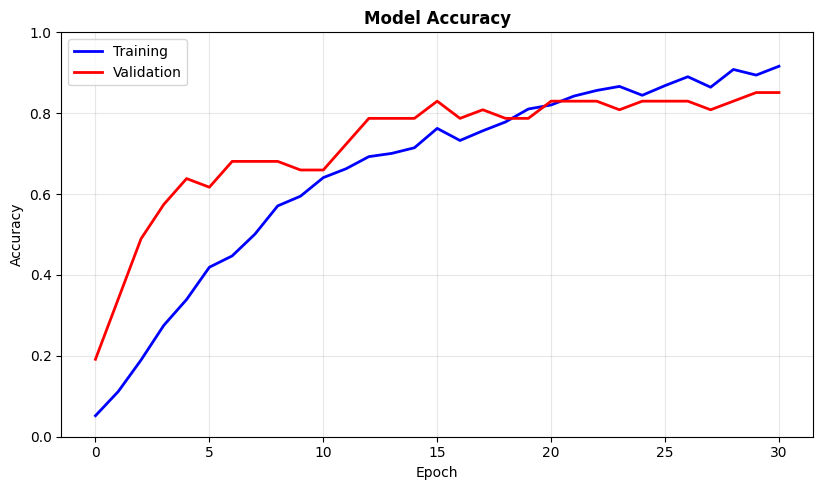

In [ ]:
# Accuracy Plot
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', label='Training', linewidth=2)
plt.plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
plt.title('Model Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_train_acc:.2%}")
print(f"Final Validation Accuracy: {final_val_acc:.2%}")
print(f"Gap: {final_train_acc - final_val_acc:.2%} ")


Final Training Accuracy: 91.62%
Final Validation Accuracy: 85.11%
Gap: 6.51% 


In [ ]:
print("The model is no longer overfitting.")

The model is no longer overfitting.


In [ ]:
def detect_humans(img_path):
    """Returns True if human faces are detected."""
    img_cv = cv2.imread(img_path)
    if img_cv is None:
        return False
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    return len(faces) > 0

In [ ]:
CONFIDENCE_THRESHOLD = 0.75

In [ ]:
# This function returns the landmark name and its location. Returns None if Human detected or Confidence Low
def predict(img_path):
    try:
        # 1. Human Validation (Reject if faces found)
        if detect_humans(img_path):
            return None

        # 2. CNN Prediction
        img = Image.open(img_path).convert('RGB')
        img_array = cv2.resize(np.array(img), (290, 290)) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        probs = model.predict(img_array, verbose=0)[0]
        pred_idx = np.argmax(probs)
        confidence = np.max(probs)

        # 3. Confidence Validation (Reject objects/non-landmarks)
        if confidence < CONFIDENCE_THRESHOLD:
            return None

        landmark = CLASS_NAMES[pred_idx].strip()
        location = LOCATION_MAP.get(landmark, "Unknown")

        # 4. OCR Verification (Optional text check)
        ocr_results = ocr_reader.readtext(img_path, detail=0)
        detected_text = " ".join(ocr_results).lower()
        landmark_keywords = landmark.lower().split()

        # If confidence is moderate, require text match
        if confidence < 0.90:
            match_found = any(keyword in detected_text for keyword in landmark_keywords if len(keyword) > 3)
            if not match_found:
                return None

        return {'name': landmark, 'place': location}

    except Exception:
        return None

In [ ]:
# Testing the model
result = predict('/content/drive/MyDrive/LandMark Images Pre-ProcessedUpdated/Adams Peak/train/pic-12.jpg')

if result:
    print(f"Landmark: {result['name']}")
    print(f"Location: {result['place']}")
else:
    print("Prediction failed or conditions not met (e.g., human detected, low confidence, or OCR mismatch).")

Landmark: Adams Peak
Location: Rathnapura, Sabaragamuwa Province, Sri Lanka


In [ ]:
model.save('/content/drive/MyDrive/FineTuned01-EfficientNetB0_CNN_Model.h5',
           save_format='h5',
           include_optimizer=False
        )
print("✅ Model saved")

✅ Model saved


In [ ]:
# Save class names
with open('/content/drive/MyDrive/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)
print("✅ Class names saved")

✅ Class names saved
